### 传统机器学习模型

In [12]:
#!pip install xgboost lightgbm optuna
import pandas as pd
import numpy as np
import os
import importlib
import optuna
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
save_dir = '/Users/neos/Desktop/Taobao DA/data_ready_for_modeling'

X_train = pd.read_parquet(f'{save_dir}/X_train.parquet')
X_val = pd.read_parquet(f'{save_dir}/X_val.parquet')
X_test = pd.read_parquet(f'{save_dir}/X_test.parquet')

y_train = pd.read_parquet(f'{save_dir}/y_train.parquet')['is_buy']
y_val = pd.read_parquet(f'{save_dir}/y_val.parquet')['is_buy']
y_test = pd.read_parquet(f'{save_dir}/y_test.parquet')['is_buy']

id_train = pd.read_parquet(f'{save_dir}/id_train.parquet')['user_id']
id_val = pd.read_parquet(f'{save_dir}/id_val.parquet')['user_id']
id_test = pd.read_parquet(f'{save_dir}/id_test.parquet')['user_id']

print(f"训练集: X={X_train.shape}, y={y_train.shape}")
print(f"验证集: X={X_val.shape}, y={y_val.shape}")
print(f"测试集: X={X_test.shape}, y={y_test.shape}")
print(f"\n训练集正样本占比: {y_train.mean()*100:.2f}%")
print(f"验证集正样本占比: {y_val.mean()*100:.2f}%")
print(f"测试集正样本占比: {y_test.mean()*100:.2f}%")

训练集: X=(6932, 118), y=(6932,)
验证集: X=(1981, 118), y=(1981,)
测试集: X=(991, 118), y=(991,)

训练集正样本占比: 66.17%
验证集正样本占比: 66.13%
测试集正样本占比: 66.20%


In [3]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    
    auc = roc_auc_score(y_val, y_pred_proba)
    acc = accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    results[name] = {'AUC': auc, '准确率': acc, '召回率': recall, 'F1': f1}
    print(f"\n{name}:")
    print(f"  AUC: {auc:.4f}")
    print(f"  准确率: {acc:.4f}")
    print(f"  召回率: {recall:.4f}")
    print(f"  F1: {f1:.4f}")


LogisticRegression:
  AUC: 0.7546
  准确率: 0.7249
  召回率: 0.8740
  F1: 0.8078

XGBoost:
  AUC: 0.7213
  准确率: 0.7052
  召回率: 0.8496
  F1: 0.7922

LightGBM:
  AUC: 0.7441
  准确率: 0.7203
  召回率: 0.8557
  F1: 0.8019


In [4]:
#Optuna超参数自动优化
optuna.logging.set_verbosity(optuna.logging.WARNING)

#logistic
def lr_objective(trial):
    C = trial.suggest_float('C', 0.001, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred)

#XGBoost
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred)

#LightGBM
def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'random_state': 42,
        'verbose': -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred)
#50次实验
study_lr = optuna.create_study(direction='maximize', study_name='LR')
study_lr.optimize(lr_objective, n_trials=50, show_progress_bar=True)
print(f"\n逻辑回归 最优AUC: {study_lr.best_value:.4f}")
print(f"逻辑回归 最优参数: {study_lr.best_params}")

study_xgb = optuna.create_study(direction='maximize', study_name='XGB')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print(f"\nXGBoost 最优AUC: {study_xgb.best_value:.4f}")
print(f"XGBoost 最优参数: {study_xgb.best_params}")

study_lgb = optuna.create_study(direction='maximize', study_name='LGB')
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print(f"\nLightGBM 最优AUC: {study_lgb.best_value:.4f}")
print(f"LightGBM 最优参数: {study_lgb.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


逻辑回归 最优AUC: 0.7654
逻辑回归 最优参数: {'C': 0.03625733509167113, 'penalty': 'l1'}


  0%|          | 0/50 [00:00<?, ?it/s]


XGBoost 最优AUC: 0.7738
XGBoost 最优参数: {'n_estimators': 155, 'max_depth': 3, 'learning_rate': 0.031027257299772494, 'subsample': 0.7810257324394645, 'colsample_bytree': 0.833306936847988, 'reg_alpha': 1.4983499685793973, 'reg_lambda': 7.148607485852492}


  0%|          | 0/50 [00:00<?, ?it/s]


LightGBM 最优AUC: 0.7759
LightGBM 最优参数: {'n_estimators': 217, 'num_leaves': 51, 'max_depth': 4, 'learning_rate': 0.026677967587280024, 'subsample': 0.727057284154737, 'colsample_bytree': 0.64658445412417, 'reg_alpha': 8.65984168754159, 'reg_lambda': 8.939865217477873}


通过Optuna进行超参数自动调优后，XGBoost模型AUC=0.7736，比基线上升约0.05，结果最好。查看三个模型的ROC curve：

验证集模型评估（Optuna最优参数）:
                       AUC     准确率     召回率      F1
LogisticRegression  0.7654  0.7314  0.8885  0.8140
XGBoost             0.7738  0.7360  0.8809  0.8153
LightGBM            0.7759  0.7410  0.8809  0.8181


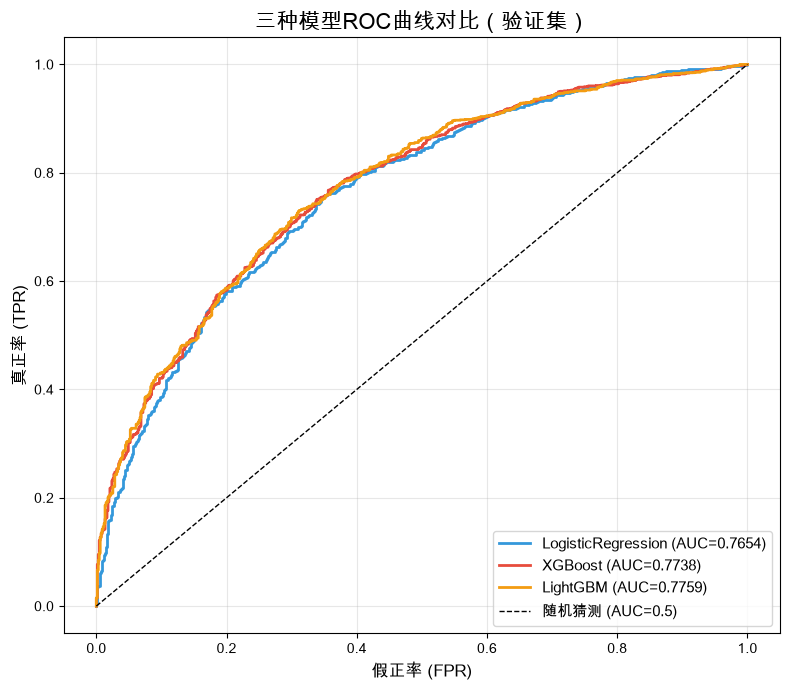

In [24]:
#最优参数建模型 
final_models = {
    'LogisticRegression': LogisticRegression(
        C=study_lr.best_params['C'],
        penalty=study_lr.best_params['penalty'],
        solver='liblinear' if study_lr.best_params['penalty'] == 'l1' else 'lbfgs',
        max_iter=1000, random_state=42
    ),
    'XGBoost': XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(**study_lgb.best_params, random_state=42, verbose=-1)
}

#在验证集评估
results_final = {}
roc_data = {}

for name, model in final_models.items():
    model.fit(X_train, y_train)              # 训练集拟合
    
    y_pred_proba = model.predict_proba(X_val)[:, 1]   # 验证集预测
    y_pred = model.predict(X_val)
    
    results_final[name] = {
        'AUC': roc_auc_score(y_val, y_pred_proba),
        '准确率': accuracy_score(y_val, y_pred),
        '召回率': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred)
    }
    
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_data[name] = (fpr, tpr)

results_final_df = pd.DataFrame(results_final).T
print("验证集模型评估（Optuna最优参数）:")
print(results_final_df.round(4))

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#3498DB', '#E74C3C', '#F39C12']

for (name, (fpr, tpr)), color in zip(roc_data.items(), colors):
    auc_val = results_final[name]['AUC']
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测 (AUC=0.5)')

ax.set_xlabel('假正率 (FPR)', fontsize=12)
ax.set_ylabel('真正率 (TPR)', fontsize=12)
ax.set_title('三种模型ROC曲线对比（验证集）', fontsize=16)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

经 Optuna 超参数调优后，三种模型在测试集上的表现整体接近，AUC 均在 0.76~0.78 之间。LightGBMt的AUC最高，其次是XGBoost稍微低于LightGBM。三者差距很小（< 0.01），模型复杂度带来的提升有限。其中LightGBM准确率（0.7410）最高，LR召回率（0.8885）最高，但模型间的差距极小。从 F1 看，LightGBM最高（0.8181），三个模型 F1 都在 0.81左右，表现相似。

综合来说，三个模型表现高度相似，但AUC表现均不算优秀（没有>0.8），可能的原因是数据量较小，特征较少。考虑后续在更庞大的特征信号更强的数据集上进行研究。


### Stacking
由于深度学习模型效果不理想，因此采用Stacking策略融合传统机器学习模型进一步优化效果。融合逻辑回归与XGBoost作为第一层基模型，通过5折分层交叉生成OOF（Out-of-Fold）预测，以其预测概率作为第二层元模型（逻辑回归）的输入特征，最终输出融合预测结果。二者权重为(LR, XGB): [1.95722768 3.09358669]

Stacking模型AUC=0.7729，介于两个基础模型之间。准确率、召回率与F1同样处于两者之间，未超过最优模型XGBoost。可见在本研究数据上，Stacking融合未能带来性能提升。可能原因如下：
1. 逻辑回归与XGBoost的模型效果本身高度相似，融合的增益有限
2. 数据规模较小，模型不足以优化到更准确的预测

In [16]:
from sklearn.model_selection import StratifiedKFold
#Optuna最优参数
lr_params = study_lr.best_params
xgb_params = study_xgb.best_params
print(f"LR最优参数: {lr_params}")
print(f"XGB最优参数: {xgb_params}")

SEED = 42
NFOLDS = 5

#5折CV生成OOF
skf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)
oof_lr = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

print("生成OOF预测...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr = y_train.iloc[tr_idx]
    
    lr_m = LogisticRegression(
        C=lr_params['C'], penalty=lr_params['penalty'],
        solver='liblinear' if lr_params['penalty'] == 'l1' else 'lbfgs',
        max_iter=1000, random_state=SEED)
    lr_m.fit(X_tr, y_tr)
    oof_lr[va_idx] = lr_m.predict_proba(X_va)[:, 1]
    
    xgb_m = XGBClassifier(**xgb_params, random_state=SEED, eval_metric='logloss')
    xgb_m.fit(X_tr, y_tr)
    oof_xgb[va_idx] = xgb_m.predict_proba(X_va)[:, 1]
    
    print(f"  Fold {fold+1} 完成")

# 基模型用全训练集训练
lr_final = LogisticRegression(
    C=lr_params['C'], penalty=lr_params['penalty'],
    solver='liblinear' if lr_params['penalty'] == 'l1' else 'lbfgs',
    max_iter=1000, random_state=SEED)
xgb_final = XGBClassifier(**xgb_params, random_state=SEED, eval_metric='logloss')
lr_final.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

# 验证集预测（用于评估）
lr_val_pred = lr_final.predict_proba(X_val)[:, 1]
xgb_val_pred = xgb_final.predict_proba(X_val)[:, 1]

# 元模型训练数据（OOF）
meta_X_train = np.column_stack([oof_lr, oof_xgb])
# 元模型评估数据（验证集）
meta_X_val = np.column_stack([lr_val_pred, xgb_val_pred])

# 训练元模型
meta_model = LogisticRegression(max_iter=1000, random_state=SEED)
meta_model.fit(meta_X_train, y_train)

print(f"\n元模型权重 (LR, XGB): {meta_model.coef_[0]}")

# ========== 在验证集评估 ==========
stack_val_pred_proba = meta_model.predict_proba(meta_X_val)[:, 1]
stack_val_pred = (stack_val_pred_proba > 0.5).astype(int)

stack_auc = roc_auc_score(y_val, stack_val_pred_proba)
stack_acc = accuracy_score(y_val, stack_val_pred)
stack_recall = recall_score(y_val, stack_val_pred)
stack_f1 = f1_score(y_val, stack_val_pred)

print(f"\nStacking验证集结果:")
print(f"  AUC: {stack_auc:.4f}")
print(f"  准确率: {stack_acc:.4f}")
print(f"  召回率: {stack_recall:.4f}")
print(f"  F1: {stack_f1:.4f}")

# 与单模型对比（验证集）
compare = pd.DataFrame({
    'LogisticRegression': {
        'AUC': roc_auc_score(y_val, lr_val_pred),
        '准确率': accuracy_score(y_val, (lr_val_pred>0.5).astype(int)),
        '召回率': recall_score(y_val, (lr_val_pred>0.5).astype(int)),
        'F1': f1_score(y_val, (lr_val_pred>0.5).astype(int))},
    'XGBoost': {
        'AUC': roc_auc_score(y_val, xgb_val_pred),
        '准确率': accuracy_score(y_val, (xgb_val_pred>0.5).astype(int)),
        '召回率': recall_score(y_val, (xgb_val_pred>0.5).astype(int)),
        'F1': f1_score(y_val, (xgb_val_pred>0.5).astype(int))},
    'Stacking': {
        'AUC': stack_auc, '准确率': stack_acc, '召回率': stack_recall, 'F1': stack_f1}
}).T

print("\n与单模型对比（验证集）:")
print(compare.round(4))

LR最优参数: {'C': 0.03625733509167113, 'penalty': 'l1'}
XGB最优参数: {'n_estimators': 155, 'max_depth': 3, 'learning_rate': 0.031027257299772494, 'subsample': 0.7810257324394645, 'colsample_bytree': 0.833306936847988, 'reg_alpha': 1.4983499685793973, 'reg_lambda': 7.148607485852492}
生成OOF预测...
  Fold 1 完成
  Fold 2 完成
  Fold 3 完成
  Fold 4 完成
  Fold 5 完成

元模型权重 (LR, XGB): [1.95722768 3.09358669]

Stacking验证集结果:
  AUC: 0.7729
  准确率: 0.7309
  召回率: 0.8771
  F1: 0.8117

与单模型对比（验证集）:
                       AUC     准确率     召回率      F1
LogisticRegression  0.7654  0.7314  0.8885  0.8140
XGBoost             0.7738  0.7360  0.8809  0.8153
Stacking            0.7729  0.7309  0.8771  0.8117


### 模型可解释性分析
逻辑回归特征系数
逻辑回归中，购买次评分m-score对用户未来7天购买决策具有最强正向影响，用户历史购买多则未来更可能买。其次是最近活跃度recency，具有明显负向作用（注意数据处理时进行过逆排序），说明距上次行为越久（值越大）则越不可能购买。活跃度相关特征如active_streak_days、rfm_score均存在正向作用，越是最近活跃、连续活跃天数高的用户越可能购买。此外其他未来更可能发生购买行为的用户特征为：
浏览→加购转化率高 
加购次数多
交互类目多


In [17]:
coef_df = pd.DataFrame({
    '特征': X_train.columns,
    '系数': lr_final.coef_[0]
})
coef_df['绝对值'] = coef_df['系数'].abs()
coef_df = coef_df.sort_values('绝对值', ascending=False)

print("逻辑回归系数（按绝对值排序，前30个）:")
print(coef_df.head(30).to_string(index=False))

print(f"\n系数为正的特征数: {(coef_df['系数'] > 0).sum()}")
print(f"系数为负的特征数: {(coef_df['系数'] < 0).sum()}")
print(f"系数为0的特征数: {(coef_df['系数'] == 0).sum()}（L1正则会把部分系数压成0）")

逻辑回归系数（按绝对值排序，前30个）:
                        特征        系数      绝对值
                   m_score  0.509360 0.509360
                   recency -0.184933 0.184933
                   r_score  0.148615 0.148615
        active_streak_days  0.137453 0.137453
                 rfm_score  0.105855 0.105855
                  monetary  0.102056 0.102056
         view_to_cart_rate  0.072836 0.072836
                cart_count  0.057586 0.057586
               svd_user_18 -0.043769 0.043769
            category_count  0.041241 0.041241
               svd_user_84 -0.039772 0.039772
            favorite_count  0.020804 0.020804
               svd_user_41  0.020372 0.020372
               svd_user_49  0.017473 0.017473
               svd_user_86  0.012632 0.012632
          cart_to_fav_rate  0.012345 0.012345
avg_behavior_interval_hour -0.009805 0.009805
             activity_high  0.006708 0.006708
               svd_user_69  0.004952 0.004952
               svd_user_85  0.003917 0.003917
             

从XGBoost sharp图中可得，对预测最重要的特征是monetary购买次数，其次依次是RFM score、recency、m_score和浏览→加购转化率。购买次数越高，用户未来7天越可能出现购买行为。RFM评分越高，未来越可能购买。recency值越大越不可能购买，意味着最近活跃度越低越不可能购买。展示出的用户购买决策核心特点与LR模型一致。 

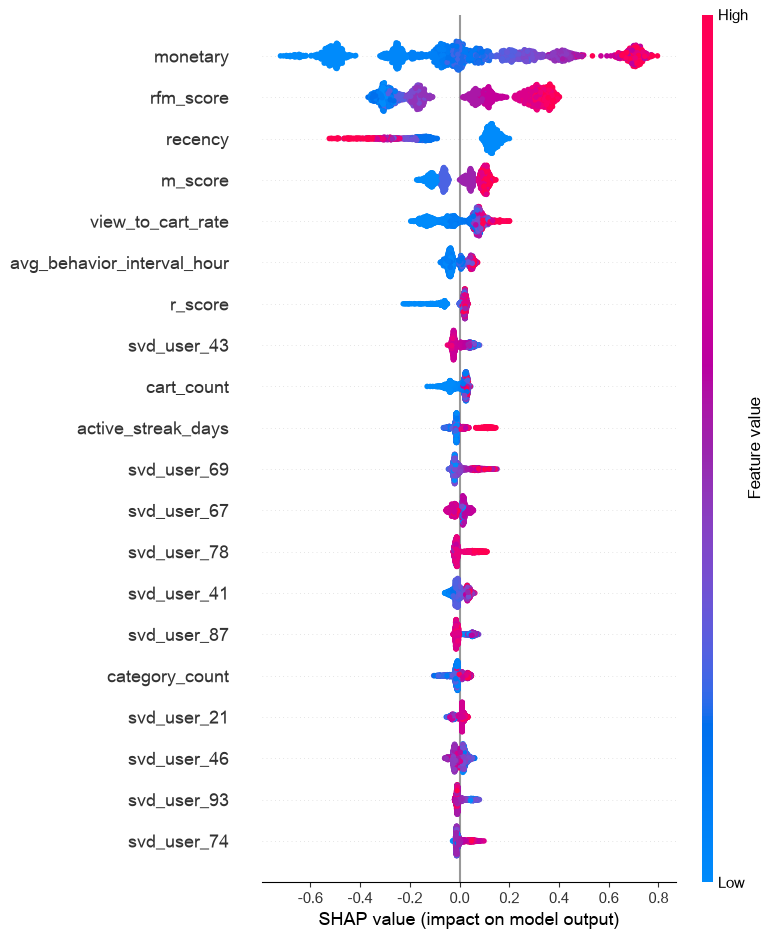

In [20]:
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, max_display=20, show=True)

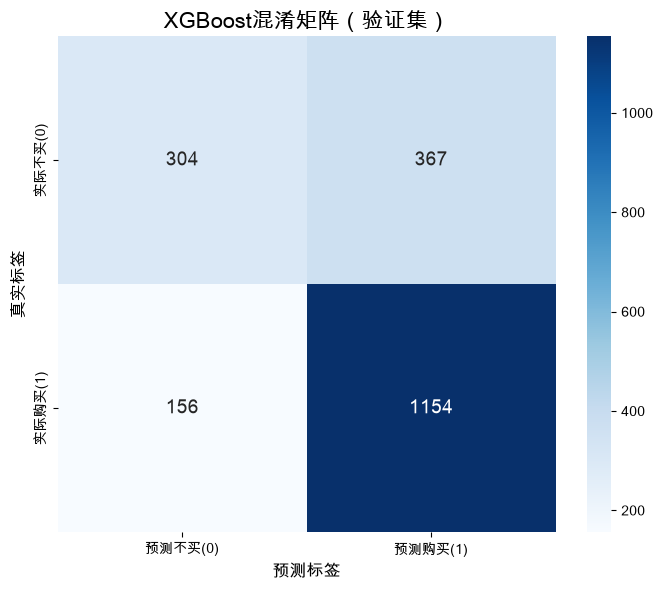

  TN(真阴性): 304
  FP(假阳性): 367
  FN(假阴性): 156
  TP(真阳性): 1154


In [19]:
from sklearn.metrics import confusion_matrix
xgb_val_pred_proba = xgb_final.predict_proba(X_val)[:, 1]
xgb_val_pred = (xgb_val_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y_val, xgb_val_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测不买(0)', '预测购买(1)'],
            yticklabels=['实际不买(0)', '实际购买(1)'],
            ax=ax, annot_kws={'size': 14})

ax.set_xlabel('预测标签', fontsize=12)
ax.set_ylabel('真实标签', fontsize=12)
ax.set_title('XGBoost混淆矩阵（验证集）', fontsize=16)
plt.tight_layout()
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"  TN(真阴性): {tn}")
print(f"  FP(假阳性): {fp}")
print(f"  FN(假阴性): {fn}")
print(f"  TP(真阳性): {tp}")

XGBoost能够较好的识别预测和实际均购买的“高意向用户"，这部分用户可直接作为精准营销、优惠券发放的目标人群。对于模型预测不买，实际也不买的低意向冷冻用户，可尝试通过短信/邮件营销尝试唤醒，但不宜投入过多资源。模型预测会购买但实际未购买的用户是分析原因与挽回操作的重点，这类人群表现出兴趣特征但是并未转化，可能原因包括：价格敏感、竞品竞争、缺少促销刺激等。针对这类用户，可采取定向优惠、限时折扣、购物车提醒等转化促进手段，挽回成本相对较低。另外一部分行为特征不典型，模型未能识别其购买意向但实际上购买的用户也值得研究，有助于发现模型遗漏的潜在购买模式，改进特征工程；或定位其购买的商品类别，分析商品特征及吸引用户的原因。

混淆矩阵显示，模型在精准识别购买用户方面表现较好，在识别实际不会购买的用户方面表现欠缺。可能是由于数据中正样本占66%左右。实际业务中，FP和FN 用户对应不同的业务成本：FP 导致营销资源浪费，FN 导致错失销售机会。未来可结合业务目标调整样本平衡。

### A/B Testing模拟
实验设计
针对模型预测"不会购买"的用户设计挽留策略，通过离线模拟 A/B 测试评估投放优惠券的经济效果。实验对象为测试集中模型预测不购买的用户，共 234 人。
对照组：不投放，用户维持原有行为
实验组：对该群体投放优惠券，假设挽回率为50%（即原本不买的用户中有50% 因优惠券刺激而转化）
参数假设：客单价 100 元，单张券成本30元
GMV（成交总额）= 购买人数 × 客单价
总ROI = 实验组 GMV / 投放成本
增量ROI = （实验组GMV - 对照组GMV）/ 投放成本

实验组净利润 8,480 元，相比对照组增加 980 元，投放策略整体有效，实现盈利。在 50% 挽回率下，原本不买的 159 人中有 80 人被成功挽回，购买人数从 75 人提升至 155 人，增幅达 107%。增量 ROI 为 1.14，略高于盈亏平衡点。每投入 1 元券成本，带来 1.14 元的增量 GMV。
其他条件不变，尝试多种挽回率，发现30%挽回率下实现盈亏平衡。在实际应用中，控制券成本、提升优惠吸引力以提高挽回率都是提升利润的重要手段。此外，本测试聚焦于全部预测不买的用户，实际上可进一步对用户进行细分（如冷冻用户，过去活跃但现在不活跃等），根据该群体特点进行精准营销。

In [23]:
# 参数假设
客单价 = 100      # 元/单
券成本 = 30      # 元/张
挽回率 = 0.5     # 50%

#测试集预测
xgb_test_pred_proba = xgb_final.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_pred_proba > 0.5).astype(int)

test_df = pd.DataFrame({
    'user_id': id_test.values,
    '真实购买': y_test.values,
    '预测购买': xgb_test_pred,
    '预测概率': xgb_test_pred_proba
})

#选定投放对象：预测不买的用户
target_users = test_df[test_df['预测购买'] == 0]
n_target = len(target_users)

print("实验设计：对预测不购买的用户投放优惠券")
print(f"测试集总用户数: {len(test_df)}")
print(f"投放对象（预测不买）: {n_target} 人")


#对照组（不投放）：用真实数据算实际结果
buy_control = int(target_users['真实购买'].sum())
gmv_control = buy_control * 客单价
cost_control = 0
profit_control = gmv_control - cost_control

print("对照组（不投放）:")
print(f"  投放人数: 0")
print(f"  实际购买人数: {buy_control}（历史真实发生）")
print(f"  GMV: {gmv_control:,} 元")
print(f"  成本: {cost_control} 元")
print(f"  净利润: {profit_control:,} 元")


#实验组（投放）
original_buy = int((target_users['真实购买'] == 1).sum())    # 原本会买的
original_non_buy = int((target_users['真实购买'] == 0).sum()) # 原本不买的

#被挽回的人数（只从"原本不买"里挽回）
recovered = int(round(original_non_buy * 挽回率))

#实验组总购买 = 原本会买的 + 被挽回的
buy_exp = original_buy + recovered
gmv_exp = buy_exp * 客单价
cost_exp = n_target * 券成本   # 给所有投放对象发券
profit_exp = gmv_exp - cost_exp

print(f"实验组（投放优惠券，挽回率{挽回率*100:.0f}%）:")
print(f"  投放人数: {n_target}")
print(f"  原本会购买(FN): {original_buy}")
print(f"  原本不购买: {original_non_buy}")
print(f"  被挽回人数: {recovered}（{original_non_buy}×{挽回率*100:.0f}%）")
print(f"  购买人数合计: {buy_exp}")
print(f"  GMV: {gmv_exp:,} 元")
print(f"  投放成本: {cost_exp:,} 元（{n_target}×{券成本}）")
print(f"  净利润: {profit_exp:,} 元")


print("实验组 vs 对照组:")
print(f"  购买人数: {buy_control} → {buy_exp} ({buy_exp-buy_control:+d})")
print(f"  GMV: {gmv_control:,} → {gmv_exp:,} ({gmv_exp-gmv_control:+,} 元)")
print(f"  成本: {cost_control} → {cost_exp:,} ({cost_exp-cost_control:+,} 元)")
print(f"  净利润: {profit_control:,} → {profit_exp:,} ({profit_exp-profit_control:+,} 元)")

if cost_exp > 0:
    roi_exp = gmv_exp / cost_exp
    roi_inc = (gmv_exp - gmv_control) / cost_exp   # 增量ROI
    print(f"\n  实验组总ROI: {roi_exp:.2f}")
    print(f"  增量ROI（挽回收益/投放成本）: {roi_inc:.2f}")

实验设计：对预测不购买的用户投放优惠券
测试集总用户数: 991
投放对象（预测不买）: 234 人
对照组（不投放）:
  投放人数: 0
  实际购买人数: 75（历史真实发生）
  GMV: 7,500 元
  成本: 0 元
  净利润: 7,500 元
实验组（投放优惠券，挽回率50%）:
  投放人数: 234
  原本会购买(FN): 75
  原本不购买: 159
  被挽回人数: 80（159×50%）
  购买人数合计: 155
  GMV: 15,500 元
  投放成本: 7,020 元（234×30）
  净利润: 8,480 元
实验组 vs 对照组:
  购买人数: 75 → 155 (+80)
  GMV: 7,500 → 15,500 (+8,000 元)
  成本: 0 → 7,020 (+7,020 元)
  净利润: 7,500 → 8,480 (+980 元)

  实验组总ROI: 2.21
  增量ROI（挽回收益/投放成本）: 1.14
